# AudioNet -- Speech Emotion Recognition
## Major Project | RAVDESS Dataset | 7 Emotions (Calm merged into Neutral)
**Architecture:** Temporal Bi-directional Multi-scale CNN (AudioNet)  
**Dataset:** RAVDESS -- 1440 clips, 24 actors, **7 emotions** (Calm merged into Neutral)  
**Validation:** 10-Fold Cross Validation  
**Fusion Ready:** Aligned with FER-2013 (7 classes) for Face+Audio scoring engine


## Cell 1 — Install Dependencies

In [ ]:
%pip install -q librosa==0.9.2
%pip install -q scikit-learn
%pip install -q pandas
%pip install -q openpyxl
print("✅ All dependencies installed!")

✅ All dependencies installed!


## Cell 2 — Verify GPU & Versions

In [2]:
import tensorflow as tf
import keras
import numpy as np
import os

print("TF Version   :", tf.__version__)
print("Keras Version:", keras.__version__)
print("NumPy Version:", np.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2026-02-28 18:16:01.374478: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772302561.398942   13322 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772302561.406414   13322 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772302561.425137   13322 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772302561.425169   13322 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772302561.425172   13322 computation_placer.cc:177] computation placer alr

TF Version   : 2.19.0
Keras Version: 3.10.0
NumPy Version: 2.0.2
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 3 — AudioNet Architecture (Keras 3.x Compatible)
**Key fix:** All tensor operations wrapped in proper Keras Layers  
- `ReverseLayer` → wraps `tf.reverse` as a Keras layer  
- `MultiplyLayer` → wraps `tf.multiply` as a Keras layer  
- `ExpandDimsLayer` → wraps `tf.expand_dims` as a Keras layer  
- `ConcatLayer` → wraps `tf.concat` as a Keras layer

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import (Layer, Activation, Conv1D, SpatialDropout1D,
                           Add, GlobalAveragePooling1D, BatchNormalization,
                           Dense, Input)
from keras.models import Model

# ─── Custom Keras-compatible layers ───────────────────────────────────────────

class ReverseLayer(Layer):
    """Reverses the time axis of a sequence — Keras 3.x safe"""
    def call(self, x):
        return tf.reverse(x, axis=[1])

class SigmoidGateLayer(Layer):
    """Sigmoid gating: element-wise multiply original_x with sigmoid(output)"""
    def call(self, inputs):
        original_x, gated = inputs
        return tf.multiply(original_x, tf.sigmoid(gated))

class ExpandDimsLayer(Layer):
    """Expands dims along axis=1"""
    def call(self, x):
        return tf.expand_dims(x, axis=1)

class ConcatLayer(Layer):
    """Concatenates list of tensors along axis=-2"""
    def call(self, inputs):
        return tf.concat(inputs, axis=-2)


# ─── Temporal Aware Block ─────────────────────────────────────────────────────

def Temporal_Aware_Block(x, i, activation, nb_filters,
                          kernel_size, dropout_rate=0.1):
    """
    TAB: Core building block of AudioNet
    - Dilated causal convolution captures temporal patterns at scale i
    - Residual connection prevents vanishing gradients
    - Sigmoid gating controls information flow
    """
    original_x = x

    # First dilated conv
    out = Conv1D(filters=nb_filters, kernel_size=kernel_size,
                 dilation_rate=i, padding='causal')(x)
    out = BatchNormalization()(out)
    out = Activation(activation)(out)
    out = SpatialDropout1D(dropout_rate)(out)

    # Second dilated conv
    out = Conv1D(filters=nb_filters, kernel_size=kernel_size,
                 dilation_rate=i, padding='causal')(out)
    out = BatchNormalization()(out)
    out = Activation(activation)(out)
    out = SpatialDropout1D(dropout_rate)(out)

    # Residual: match channels if needed
    if original_x.shape[-1] != nb_filters:
        original_x = Conv1D(filters=nb_filters,
                            kernel_size=1, padding='same')(original_x)

    # Sigmoid gate (Keras layer — no raw tf ops on symbolic tensors)
    F_x = SigmoidGateLayer()([original_x, out])
    return F_x


# ─── AudioNet ─────────────────────────────────────────────────────────────────

def build_audionet(input_shape, num_classes,
                   nb_filters=39, kernel_size=2, nb_stacks=1,
                   dilations=8, activation='relu', dropout_rate=0.1,
                   lr=0.001, beta1=0.93, beta2=0.98):
    """
    Builds the full AudioNet model graph.

    Architecture:
    Input MFCC
        ↓
    Forward stream  →  TAB x8 (dilations 1,2,4,...128)
                                    ↓ add at each scale
    Backward stream →  TAB x8      ↓
    (reversed)          ↓  → GlobalAvgPool → expand_dims
                        
    All 8 scale outputs → concatenate → WeightLayer → Dense(softmax)
    """
    inputs = Input(shape=input_shape, name='mfcc_input')

    # Forward and backward streams
    forward  = inputs
    backward = ReverseLayer(name='reverse')(inputs)

    # Initial projection
    forward  = Conv1D(nb_filters, kernel_size=1, padding='causal',
                      name='proj_forward')(forward)
    backward = Conv1D(nb_filters, kernel_size=1, padding='causal',
                      name='proj_backward')(backward)

    skip_connections = []

    # Multi-scale TABs with exponentially increasing dilation
    for stack in range(nb_stacks):
        for d_idx, d in enumerate([2**i for i in range(dilations)]):
            forward  = Temporal_Aware_Block(forward,  d, activation,
                                            nb_filters, kernel_size, dropout_rate)
            backward = Temporal_Aware_Block(backward, d, activation,
                                            nb_filters, kernel_size, dropout_rate)

            # Combine forward + backward at this scale
            merged = Add(name=f'add_scale_{stack}_{d_idx}')([forward, backward])
            pooled = GlobalAveragePooling1D()(merged)
            expanded = ExpandDimsLayer()(pooled)
            skip_connections.append(expanded)

    # Concatenate all scale representations
    if len(skip_connections) == 1:
        multi_scale = skip_connections[0]
    else:
        multi_scale = ConcatLayer()(skip_connections)

    # Learnable weighted aggregation across scales
    # multi_scale shape: (batch, num_scales, nb_filters)
    # Transpose → (batch, nb_filters, num_scales) → dense → squeeze
    transposed = tf.keras.layers.Permute((2, 1))(multi_scale)
    weighted   = Dense(1, use_bias=False, name='scale_weights')(transposed)
    squeezed   = tf.keras.layers.Reshape((nb_filters,))(weighted)

    # Final classification
    outputs = Dense(num_classes, activation='softmax', name='emotion_output')(squeezed)

    model = Model(inputs=inputs, outputs=outputs, name='AudioNet')
    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(
            learning_rate=lr, beta_1=beta1, beta_2=beta2, epsilon=1e-8),
        metrics=['accuracy'])

    return model


print("✅ AudioNet Architecture Loaded! (Keras 3.x Compatible)")

✅ AudioNet Architecture Loaded! (Keras 3.x Compatible)


## Cell 4 -- AudioNet Training Wrapper
10-fold cross validation with:
- **Calm -> Neutral merge** (7 classes, FER-2013 aligned)
- Label smoothing (factor=0.1)
- `ModelCheckpoint` -- saves best epoch per fold
- `EarlyStopping` -- stops after 60 epochs of no val_accuracy improvement
- `ReduceLROnPlateau` -- halves LR on val_loss plateau
- **Global best fold** tracked by comparing best-epoch val_accuracy across ALL folds
- Best fold saved as both `.weights.h5` and full `.keras`
- Confusion matrix + Excel report per fold


In [4]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import KFold
from keras import callbacks
import datetime
import pandas as pd
import copy
import shutil


def smooth_labels(labels, factor=0.1):
    """Label smoothing -- reduces overconfidence"""
    labels = labels * (1 - factor)
    labels = labels + (factor / labels.shape[1])
    return labels


class AudioNet_Model:
    """
    AudioNet Training & Evaluation Wrapper
    - 7 classes (Calm merged into Neutral, aligned with FER-2013)
    - 10-fold cross validation
    - Saves BEST fold model by comparing val_accuracy across ALL folds
    - Stores per-fold history for plotting
    - Confusion matrices + Excel export
    """

    def __init__(self, args, input_shape, class_label):
        self.args             = args
        self.data_shape       = input_shape
        self.num_classes      = len(class_label)
        self.class_label      = class_label
        self.matrix           = []
        self.eva_matrix       = []
        self.acc              = 0
        self.trained          = False
        self.fold_histories   = []
        self.fold_accuracies  = []
        self.best_fold_idx    = None
        self.best_fold_acc    = 0.0
        self.best_weight_path = None
        self.best_keras_path  = None
        print("AudioNet_Model INITIALIZED")
        print(f"   Input Shape  : {input_shape}")
        print(f"   Num Classes  : {self.num_classes}  (7 -- Calm merged into Neutral)")
        print(f"   Class Labels : {list(class_label)}")

    def create_model(self):
        model = build_audionet(
            input_shape  = self.data_shape,
            num_classes  = self.num_classes,
            nb_filters   = self.args['filter_size'],
            kernel_size  = self.args['kernel_size'],
            nb_stacks    = self.args['stack_size'],
            dilations    = self.args['dilation_size'],
            activation   = self.args['activation'],
            dropout_rate = self.args['dropout'],
            lr           = self.args['lr'],
            beta1        = self.args['beta1'],
            beta2        = self.args['beta2'],
        )
        return model

    def train(self, x, y):
        os.makedirs(self.args['model_path'],  exist_ok=True)
        os.makedirs(self.args['result_path'], exist_ok=True)

        now_time = datetime.datetime.strftime(
            datetime.datetime.now(), '%Y-%m-%d_%H-%M-%S')

        kfold = KFold(
            n_splits     = self.args['split_fold'],
            shuffle      = True,
            random_state = self.args['random_seed'])

        folder = (self.args['model_path'] + self.args['data'] + '_' +
                  str(self.args['random_seed']) + '_' + now_time)
        os.makedirs(folder, exist_ok=True)

        best_weight_path_global = folder + '/BEST_fold.weights.h5'
        best_keras_path_global  = folder + '/BEST_fold_model.keras'

        avg_accuracy = 0.0
        fold_idx     = 1

        print(f"{'='*60}")
        print(f"  STARTING {self.args['split_fold']}-FOLD CROSS VALIDATION")
        print(f"  Classes : {list(self.class_label)}")
        print(f"{'='*60}")

        for train_idx, test_idx in kfold.split(x, y):
            print(f"\n{'─'*60}")
            print(f"  FOLD {fold_idx} / {self.args['split_fold']}")
            print(f"{'─'*60}")

            model   = self.create_model()
            y_train = smooth_labels(copy.deepcopy(y[train_idx]), 0.1)

            temp_weight_path = folder + f'/fold_{fold_idx}_temp.weights.h5'

            ckpt = callbacks.ModelCheckpoint(
                temp_weight_path,
                monitor           = 'val_accuracy',
                verbose           = 0,
                save_weights_only = True,
                save_best_only    = True)

            reduce_lr = callbacks.ReduceLROnPlateau(
                monitor  = 'val_loss',
                factor   = 0.5,
                patience = 20,
                min_lr   = 1e-6,
                verbose  = 0)

            early_stop = callbacks.EarlyStopping(
                monitor              = 'val_accuracy',
                patience             = 60,
                restore_best_weights = False,
                verbose              = 1)

            hist = model.fit(
                x[train_idx], y_train,
                validation_data = (x[test_idx], y[test_idx]),
                batch_size      = self.args['batch_size'],
                epochs          = self.args['epoch'],
                verbose         = 1,
                callbacks       = [ckpt, reduce_lr, early_stop])

            # Store full history for plotting
            self.fold_histories.append(hist.history)

            # Load best epoch weights for this fold
            model.load_weights(temp_weight_path)
            eval_result  = model.evaluate(x[test_idx], y[test_idx], verbose=0)
            fold_acc     = eval_result[1]
            avg_accuracy += fold_acc
            self.fold_accuracies.append(fold_acc)

            print(f"  Fold {fold_idx} Best Val Accuracy : {round(fold_acc*100, 2):.2f}%")
            print(f"  Running Average           : {round(avg_accuracy*100/fold_idx, 2):.2f}%")

            # ── Compare with global best -- save if better ──────────────────
            if fold_acc > self.best_fold_acc:
                self.best_fold_acc = fold_acc
                self.best_fold_idx = fold_idx
                shutil.copyfile(temp_weight_path, best_weight_path_global)
                self.best_weight_path = best_weight_path_global
                model.save(best_keras_path_global)
                self.best_keras_path = best_keras_path_global
                print(f"  BEST FOLD UPDATED!  Val Acc = {round(fold_acc*100, 2):.2f}%")
                print(f"  Saved --> BEST_fold.weights.h5 + BEST_fold_model.keras")
            else:
                print(f"  (Not best -- Fold {self.best_fold_idx} still leads at {round(self.best_fold_acc*100, 2):.2f}%)")

            # Clean temp weights
            if os.path.exists(temp_weight_path):
                os.remove(temp_weight_path)

            y_pred = model.predict(x[test_idx])
            self.matrix.append(confusion_matrix(
                np.argmax(y[test_idx], axis=1),
                np.argmax(y_pred,      axis=1)))

            em = classification_report(
                np.argmax(y[test_idx], axis=1),
                np.argmax(y_pred,      axis=1),
                target_names = self.class_label,
                output_dict  = True)
            self.eva_matrix.append(em)
            print(classification_report(
                np.argmax(y[test_idx], axis=1),
                np.argmax(y_pred,      axis=1),
                target_names = self.class_label))

            del model
            keras.backend.clear_session()
            fold_idx += 1

        final_acc = avg_accuracy / self.args['split_fold']
        print(f"\n{'='*60}")
        print(f"  TRAINING COMPLETE!")
        print(f"  Avg Val Accuracy  : {round(final_acc*100, 2):.2f}%")
        print(f"  Best Fold         : Fold {self.best_fold_idx}  ({round(self.best_fold_acc*100, 2):.2f}%)")
        print(f"  Weights saved     : {self.best_weight_path}")
        print(f"  Model saved       : {self.best_keras_path}")
        print(f"{'='*60}")

        # Excel export
        xl_path = (self.args['result_path'] + self.args['data'] + '_' +
                   str(self.args['split_fold']) + 'fold_' +
                   str(round(final_acc * 10000) / 100) + '_' +
                   str(self.args['random_seed']) + '_' + now_time + '.xlsx')
        writer = pd.ExcelWriter(xl_path)
        for idx, cm in enumerate(self.matrix):
            temp = {' ': list(self.class_label)}
            for j in range(len(cm)):
                temp[self.class_label[j]] = list(cm[j])
            pd.DataFrame(temp).to_excel(writer, sheet_name=str(idx), index=False)
            pd.DataFrame(self.eva_matrix[idx]).transpose().to_excel(
                writer, sheet_name=str(idx) + '_eval')
        writer.close()
        print(f"  Excel results     : {xl_path}")

        self.acc     = final_acc
        self.trained = True
        return final_acc


print("AudioNet_Model Class Loaded!")
print("  --> 7 classes (Calm merged into Neutral)")
print("  --> Best fold saved as .weights.h5 + full .keras")
print("  --> EarlyStopping + ReduceLROnPlateau active")


AudioNet_Model Class Loaded!
  --> 7 classes (Calm merged into Neutral)
  --> Best fold saved as .weights.h5 + full .keras
  --> EarlyStopping + ReduceLROnPlateau active


## Cell 5 — Configuration

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# OPTION 1: Calm -> Neutral merge so RAVDESS aligns with FER-2013 (7 classes)
# Original RAVDESS: 0=angry 1=calm 2=disgust 3=fear 4=happy 5=neutral 6=sad 7=surprise
# After merge:      0=angry       1=disgust  2=fear  3=happy 4=neutral 5=sad 6=surprise
# ─────────────────────────────────────────────────────────────────────────────

# 7 classes -- aligned with FER-2013
RAVDE_CLASS_LABELS = (
    "angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"
)

# Mapping: original 8-class index --> merged 7-class index
CALM_MERGE_MAP = {
    0: 0,   # angry    --> angry
    1: 4,   # calm     --> neutral   <-- MERGED
    2: 1,   # disgust  --> disgust
    3: 2,   # fear     --> fear
    4: 3,   # happy    --> happy
    5: 4,   # neutral  --> neutral
    6: 5,   # sad      --> sad
    7: 6,   # surprise --> surprise
}

args = {
    'data'         : 'RAVDE',
    'model_path'   : './Models/',
    'result_path'  : './Results/',
    'lr'           : 0.001,
    'beta1'        : 0.93,
    'beta2'        : 0.98,
    'batch_size'   : 64,
    'epoch'        : 500,
    'dropout'      : 0.1,
    'random_seed'  : 46,
    'activation'   : 'relu',
    'filter_size'  : 39,
    'dilation_size': 8,
    'kernel_size'  : 2,
    'stack_size'   : 1,
    'split_fold'   : 10,
    'gpu'          : '0'
}

print("Configuration Set!")
print(f"   Dataset      : RAVDESS  (Calm -> Neutral merged)")
print(f"   Classes      : {RAVDE_CLASS_LABELS}")
print(f"   Num Classes  : {len(RAVDE_CLASS_LABELS)}  (was 8, now 7)")
print(f"   Epochs       : {args['epoch']}")
print(f"   Batch Size   : {args['batch_size']}")
print(f"   Folds        : {args['split_fold']}")
print()
print("Calm -> Neutral Merge Map:")
_orig = ['angry','calm','disgust','fear','happy','neutral','sad','surprise']
for old_idx, new_idx in CALM_MERGE_MAP.items():
    arrow = "  <-- MERGED" if old_idx == 1 else ""
    print(f"   [{old_idx}] {_orig[old_idx]:<10} --> [{new_idx}] {RAVDE_CLASS_LABELS[new_idx]}{arrow}")


Configuration Set!
   Dataset      : RAVDESS  (Calm -> Neutral merged)
   Classes      : ('angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise')
   Num Classes  : 7  (was 8, now 7)
   Epochs       : 500
   Batch Size   : 64
   Folds        : 10

Calm -> Neutral Merge Map:
   [0] angry      --> [0] angry
   [1] calm       --> [4] neutral  <-- MERGED
   [2] disgust    --> [1] disgust
   [3] fear       --> [2] fear
   [4] happy      --> [3] happy
   [5] neutral    --> [4] neutral
   [6] sad        --> [5] sad
   [7] surprise   --> [6] surprise


## Cell 6 -- Load & Merge MFCC Features
Loading `RAVDE.npy` -- 39-dim MFCC features.  
**Applying Calm -> Neutral merge**: converts 8-class one-hot labels to 7-class one-hot labels.


In [6]:
MFCC_PATH = "/kaggle/input/models/sandipbiswal711/extract-features-of-ravdess-audio/pytorch/default/1/RAVDE.npy"

print("Loading MFCC features...")
data     = np.load(MFCC_PATH, allow_pickle=True).item()
x_source = data["x"].astype(np.float32)
y_raw    = data["y"].astype(np.float32)   # original 8-class one-hot

print(f"Raw features loaded:")
print(f"   X shape : {x_source.shape}")
print(f"   Y shape : {y_raw.shape}  (8 classes, includes Calm)")
print()

# ── Apply Calm -> Neutral merge ────────────────────────────────────────────
# Step 1: one-hot -> int
y_int_orig   = np.argmax(y_raw, axis=1)
# Step 2: remap using CALM_MERGE_MAP
y_int_merged = np.array([CALM_MERGE_MAP[i] for i in y_int_orig])
# Step 3: back to 7-class one-hot
y_source = np.eye(len(RAVDE_CLASS_LABELS), dtype=np.float32)[y_int_merged]

calm_count   = int(np.sum(y_int_orig == 1))
neutral_orig = int(np.sum(y_int_orig == 5))
neutral_new  = int(np.sum(y_int_merged == 4))

print("Calm -> Neutral Merge Applied!")
print(f"   Calm samples merged       : {calm_count}")
print(f"   Neutral count (before)    : {neutral_orig}")
print(f"   Neutral count (after)     : {neutral_new}  (+{calm_count})")
print()
print(f"   X shape : {x_source.shape}")
print(f"   Y shape : {y_source.shape}  (7 classes)")
print()
print("Merged Class Distribution:")
for i, label in enumerate(RAVDE_CLASS_LABELS):
    count = int(np.sum(y_int_merged == i))
    bar   = '#' * (count // 30)
    print(f"   [{i}] {label:<10}: {count:>4}  {bar}")


Loading MFCC features...
Raw features loaded:
   X shape : (1440, 215, 39)
   Y shape : (1440, 8)  (8 classes, includes Calm)

Calm -> Neutral Merge Applied!
   Calm samples merged       : 192
   Neutral count (before)    : 96
   Neutral count (after)     : 288  (+192)

   X shape : (1440, 215, 39)
   Y shape : (1440, 7)  (7 classes)

Merged Class Distribution:
   [0] angry     :  192  ######
   [1] disgust   :  192  ######
   [2] fear      :  192  ######
   [3] happy     :  192  ######
   [4] neutral   :  288  #########
   [5] sad       :  192  ######
   [6] surprise  :  192  ######


## Cell 7 — Data Visualization

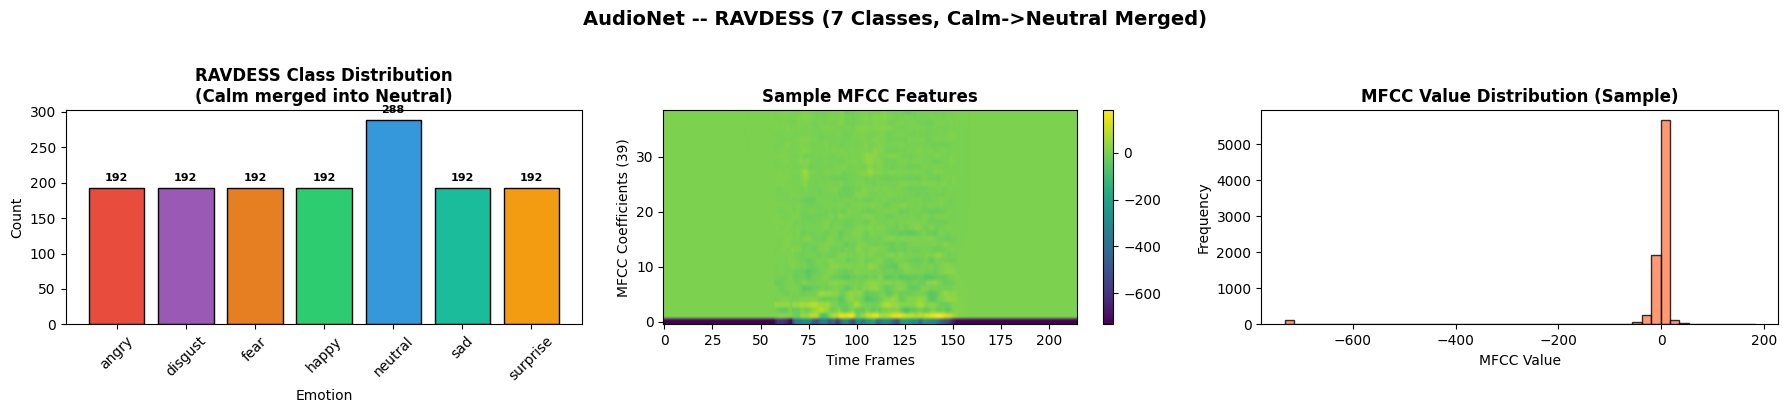

Visualization saved!


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

class_counts = np.sum(y_source, axis=0)
colors = ['#e74c3c','#9b59b6','#e67e22','#2ecc71','#3498db','#1abc9c','#f39c12']
axes[0].bar(RAVDE_CLASS_LABELS, class_counts, color=colors, edgecolor='black')
axes[0].set_title('RAVDESS Class Distribution\n(Calm merged into Neutral)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 10, str(int(v)), ha='center', fontsize=8, fontweight='bold')

img = axes[1].imshow(x_source[0].T, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('Sample MFCC Features', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Frames')
axes[1].set_ylabel('MFCC Coefficients (39)')
plt.colorbar(img, ax=axes[1])

axes[2].hist(x_source[0].flatten(), bins=50, color='coral', edgecolor='black', alpha=0.8)
axes[2].set_title('MFCC Value Distribution (Sample)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('MFCC Value')
axes[2].set_ylabel('Frequency')

plt.suptitle('AudioNet -- RAVDESS (7 Classes, Calm->Neutral Merged)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/data_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved!")


## Cell 8 — Model Summary (Check Before Training)
Run this to verify the model graph is correct before the long training step.

In [8]:
test_model = build_audionet(
    input_shape  = x_source.shape[1:],
    num_classes  = len(RAVDE_CLASS_LABELS),   # 7
    nb_filters   = args['filter_size'],
    kernel_size  = args['kernel_size'],
    nb_stacks    = args['stack_size'],
    dilations    = args['dilation_size'],
    activation   = args['activation'],
    dropout_rate = args['dropout'],
    lr           = args['lr'],
    beta1        = args['beta1'],
    beta2        = args['beta2'],
)
test_model.summary()
del test_model
keras.backend.clear_session()
print("\nModel graph valid -- 7-class output (Calm->Neutral merged, FER-2013 aligned)")


I0000 00:00:1772302573.493497   13322 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "AudioNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mfcc_input          │ (None, 215, 39)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reverse             │ (None, 215, 39)   │          0 │ mfcc_input[0][0]  │
│ (ReverseLayer)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_forward        │ (None, 215, 39)   │      1,560 │ mfcc_input[0][0]  │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_backward       │ (None, 215, 39)   │      1,560 │ reverse[0][0]     │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 215, 39)   │      3,081 │ proj_forward[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 215, 39)   │      3,081 │ proj_backward[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 215, 39)   │        156 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 215, 39)   │        156 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 215, 39)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 215, 39)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 215, 39)   │          0 │ activation[0][0]  │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 215, 39)   │          0 │ activation_2[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 215, 39)   │      3,081 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 215, 39)   │      3,081 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 215, 39)   │        156 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 215, 39)   │        156 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 215, 39)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 215, 39)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 106,992 (417.94 KB)

 Trainable params: 104,496 (408.19 KB)

 Non-trainable params: 2,496 (9.75 KB)


Model graph valid -- 7-class output (Calm->Neutral merged, FER-2013 aligned)


## Cell 9 -- Train AudioNet (7 Classes)
**Estimated time on Kaggle P100: 2-3 hours**  
- EarlyStopping active (patience=60) -- may finish faster than 500 epochs  
- Best fold weights saved automatically by comparing all fold accuracies  


In [9]:
os.environ['CUDA_VISIBLE_DEVICES'] = args['gpu']

audionet = AudioNet_Model(
    args        = args,
    input_shape = x_source.shape[1:],
    class_label = RAVDE_CLASS_LABELS        # 7 classes
)

print("\nStarting AudioNet Training on RAVDESS (7 classes)...")
print("  Calm has been merged into Neutral")
print("  Aligned with FER-2013 for Face+Audio fusion")
print("  Keep this tab open!\n")

final_accuracy = audionet.train(x_source, y_source)

print(f"\nTRAINING COMPLETE!")
print(f"   Final Avg Accuracy : {round(final_accuracy*100, 2):.2f}%")
print(f"   Best Fold          : Fold {audionet.best_fold_idx}  ({round(audionet.best_fold_acc*100, 2):.2f}%)")
print(f"   Best Model (.keras): {audionet.best_keras_path}")


AudioNet_Model INITIALIZED
   Input Shape  : (215, 39)
   Num Classes  : 7  (7 -- Calm merged into Neutral)
   Class Labels : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Starting AudioNet Training on RAVDESS (7 classes)...
  Calm has been merged into Neutral
  Aligned with FER-2013 for Face+Audio fusion
  Keep this tab open!

  STARTING 10-FOLD CROSS VALIDATION
  Classes : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

────────────────────────────────────────────────────────────
  FOLD 1 / 10
────────────────────────────────────────────────────────────
Epoch 1/500


I0000 00:00:1772302600.894656   13405 service.cc:152] XLA service 0x7b39082a3d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772302600.894696   13405 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772302605.478711   13405 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.1133 - loss: 58.5157  

I0000 00:00:1772302633.494273   13405 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


21/21 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.1775 - loss: 35.5488 - val_accuracy: 0.1597 - val_loss: 23.9391 - learning_rate: 0.0010
Epoch 2/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.2340 - loss: 8.6505 - val_accuracy: 0.2292 - val_loss: 15.8521 - learning_rate: 0.0010
Epoch 3/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.2685 - loss: 3.8431 - val_accuracy: 0.1042 - val_loss: 9.1421 - learning_rate: 0.0010
Epoch 4/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.2963 - loss: 3.0756 - val_accuracy: 0.0903 - val_loss: 6.5837 - learning_rate: 0.0010
Epoch 5/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.3225 - loss: 2.7310 - val_accuracy: 0.1458 - val_loss: 5.8329 - learning_rate: 0.0010
Epoch 6/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.3059 - loss: 2.4891 - val_accuracy: 0.1597 - val_loss: 5.9334 - learning_rate: 0.0010
Epoch 7/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.3384 - loss: 2.2921 - val_accura

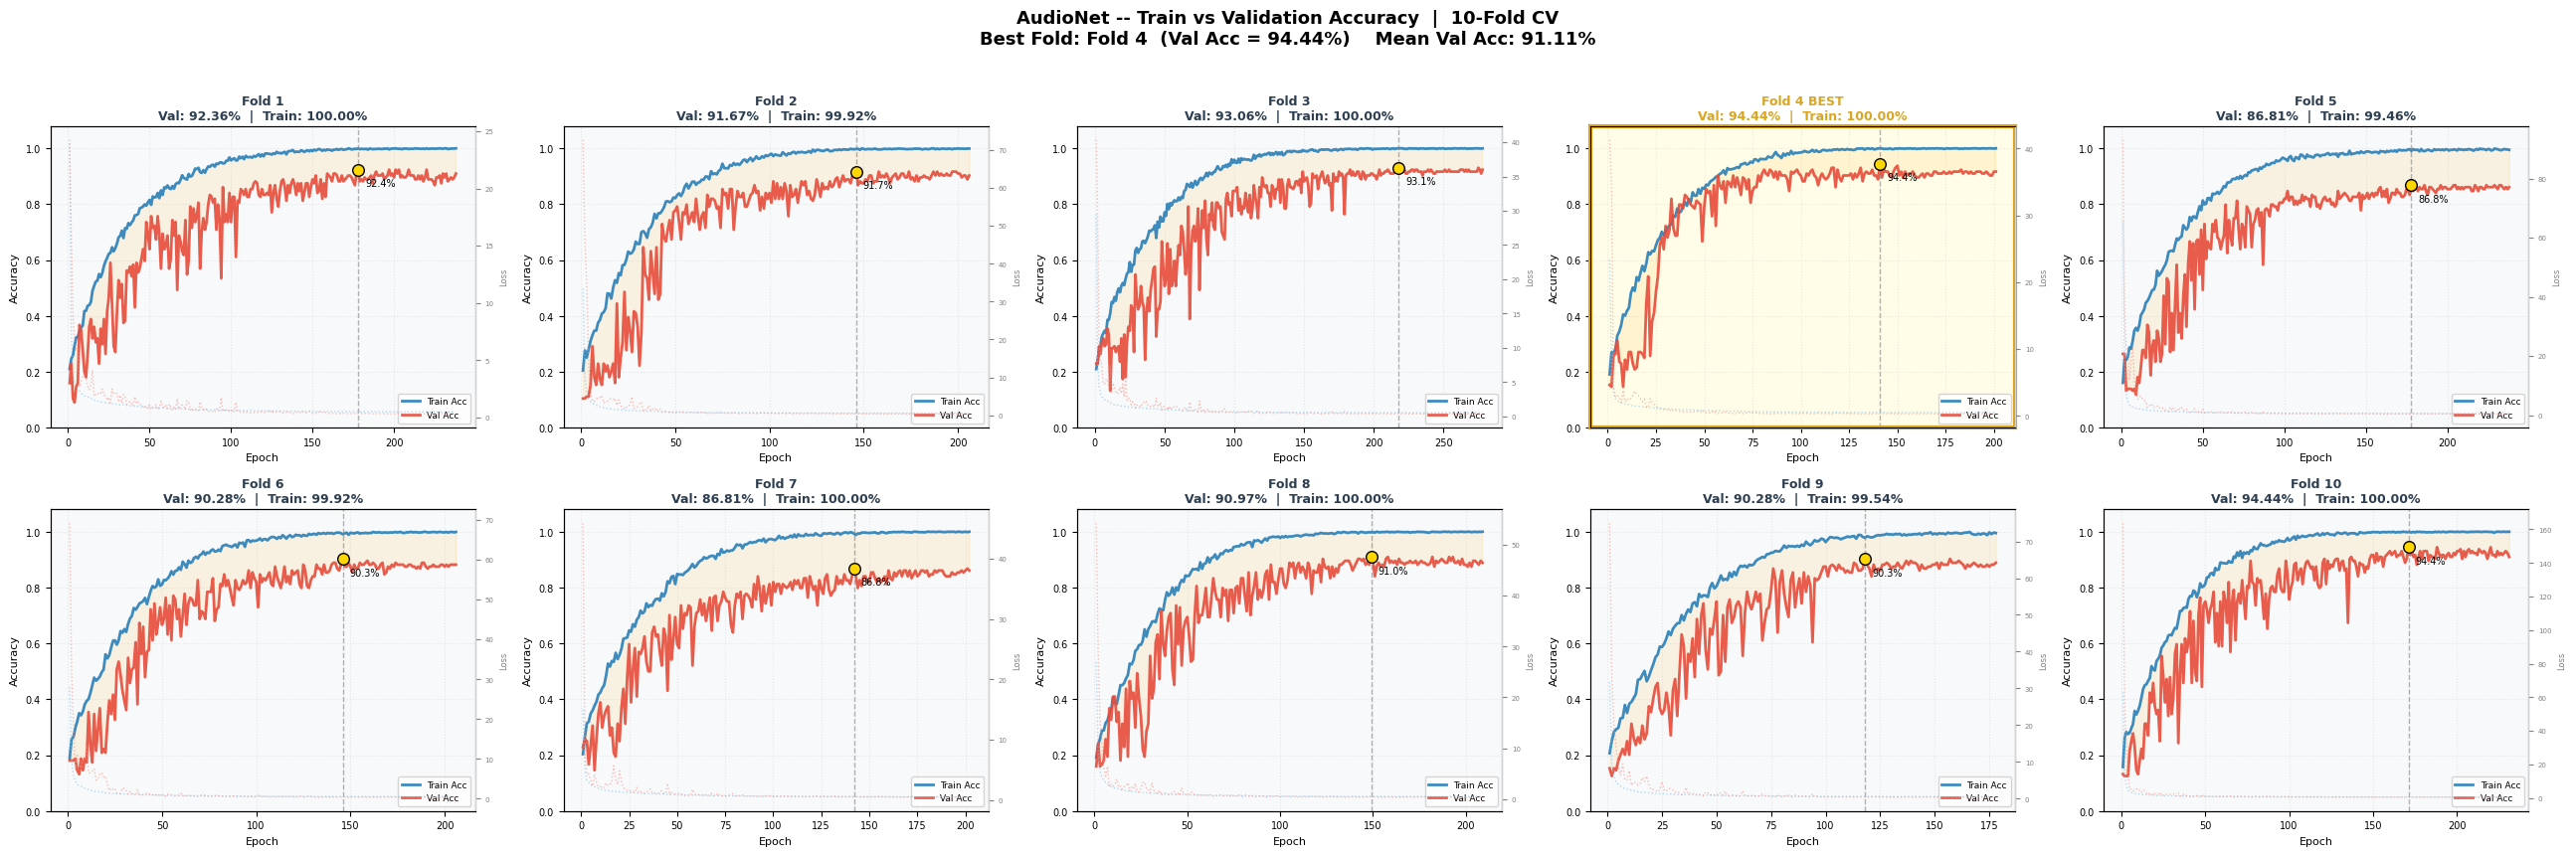

Plot saved --> /kaggle/working/train_val_accuracy_all_folds.png

  Fold      Best Val Acc   Final Train Acc  Peak Epoch
────────────────────────────────────────────────────────────
  Fold 1            92.36%           100.00%  ep  178/238
  Fold 2            91.67%            99.92%  ep  146/206
  Fold 3            93.06%           100.00%  ep  218/278
  Fold 4            94.44%           100.00%  ep  141/201  <-- BEST
  Fold 5            86.81%            99.46%  ep  178/238
  Fold 6            90.28%            99.92%  ep  146/206
  Fold 7            86.81%           100.00%  ep  142/202
  Fold 8            90.97%           100.00%  ep  149/209
  Fold 9            90.28%            99.54%  ep  118/178
  Fold 10           94.44%           100.00%  ep  171/231
────────────────────────────────────────────────────────────
  Mean            91.11%
  Best            94.44%  (Fold 4)


In [15]:
## Cell 9b -- Train vs Validation Accuracy -- All Folds
# Run AFTER training. One subplot per fold. Best fold highlighted in gold.

import matplotlib.pyplot as plt
import numpy as np

assert audionet.trained, "Run training cell first!"

n_folds  = len(audionet.fold_histories)
avg_acc  = sum(audionet.fold_accuracies) / n_folds
cols     = min(5, n_folds)
rows     = (n_folds + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5.2, rows * 4.2))
axes_flat = np.array(axes).flatten()

fig.suptitle(
    f"AudioNet -- Train vs Validation Accuracy  |  {n_folds}-Fold CV\n"
    f"Best Fold: Fold {audionet.best_fold_idx}  "
    f"(Val Acc = {audionet.best_fold_acc*100:.2f}%)    "
    f"Mean Val Acc: {avg_acc*100:.2f}%",
    fontsize=13, fontweight='bold', y=1.02)

for fold_i, hist in enumerate(audionet.fold_histories):
    ax      = axes_flat[fold_i]
    fnum    = fold_i + 1
    is_best = (fnum == audionet.best_fold_idx)

    train_acc = hist['accuracy']
    val_acc   = hist['val_accuracy']
    epochs    = range(1, len(train_acc) + 1)

    ax.plot(epochs, train_acc, label='Train Acc', color='#2980b9', linewidth=2.0, alpha=0.9)
    ax.plot(epochs, val_acc,   label='Val Acc',   color='#e74c3c', linewidth=2.0, alpha=0.9)

    # Shade overfitting gap
    ax.fill_between(epochs, train_acc, val_acc,
                    where=[t >= v for t, v in zip(train_acc, val_acc)],
                    alpha=0.10, color='orange', interpolate=True)

    # Mark peak val accuracy
    peak_epoch = int(np.argmax(val_acc)) + 1
    peak_val   = float(max(val_acc))
    ax.axvline(peak_epoch, color='gray', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.scatter([peak_epoch], [peak_val],
               color='gold', s=70, zorder=6,
               edgecolors='black', linewidths=1.0)
    ax.annotate(f'{peak_val*100:.1f}%',
                xy=(peak_epoch, peak_val),
                xytext=(5, -12), textcoords='offset points',
                fontsize=7, color='black')

    # Loss on secondary axis
    if 'loss' in hist and 'val_loss' in hist:
        ax2 = ax.twinx()
        ax2.plot(epochs, hist['loss'],     color='#85c1e9', linewidth=1.0,
                 linestyle=':', alpha=0.6, label='Train Loss')
        ax2.plot(epochs, hist['val_loss'], color='#f1948a', linewidth=1.0,
                 linestyle=':', alpha=0.6, label='Val Loss')
        ax2.set_ylabel('Loss', fontsize=6, color='gray')
        ax2.tick_params(labelsize=5, colors='gray')
        ax2.spines['right'].set_color('lightgray')

    star        = " BEST" if is_best else ""
    title_color = 'goldenrod' if is_best else '#2c3e50'
    ax.set_title(
        f"Fold {fnum}{star}\nVal: {audionet.fold_accuracies[fold_i]*100:.2f}%  |  Train: {train_acc[-1]*100:.2f}%",
        fontsize=9, fontweight='bold', color=title_color, pad=5)

    if is_best:
        for spine in ax.spines.values():
            spine.set_edgecolor('goldenrod')
            spine.set_linewidth(3.0)
        ax.set_facecolor('#fffde7')
    else:
        ax.set_facecolor('#f8f9fa')

    ax.set_xlabel("Epoch", fontsize=8)
    ax.set_ylabel("Accuracy", fontsize=8)
    ax.set_ylim(0.0, 1.08)
    ax.legend(fontsize=6.5, loc='lower right', framealpha=0.8)
    ax.grid(True, alpha=0.25, linestyle=':')
    ax.tick_params(labelsize=7)

for j in range(n_folds, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
save_path = '/kaggle/working/train_val_accuracy_all_folds.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved --> {save_path}")

print(f"\n{'='*60}")
print(f"  {'Fold':<8} {'Best Val Acc':>13}  {'Final Train Acc':>16}  {'Peak Epoch':>10}")
print(f"{'─'*60}")
for i, (h, va) in enumerate(zip(audionet.fold_histories, audionet.fold_accuracies)):
    ta       = h['accuracy'][-1]
    peak_ep  = int(np.argmax(h['val_accuracy'])) + 1
    total_ep = len(h['accuracy'])
    star     = "  <-- BEST" if (i+1) == audionet.best_fold_idx else ""
    print(f"  Fold {i+1:<4}  {va*100:>12.2f}%  {ta*100:>15.2f}%  ep {peak_ep:>4}/{total_ep}{star}")
print(f"{'─'*60}")
print(f"  {'Mean':<8} {avg_acc*100:>12.2f}%")
print(f"  {'Best':<8} {audionet.best_fold_acc*100:>12.2f}%  (Fold {audionet.best_fold_idx})")
print(f"{'='*60}")


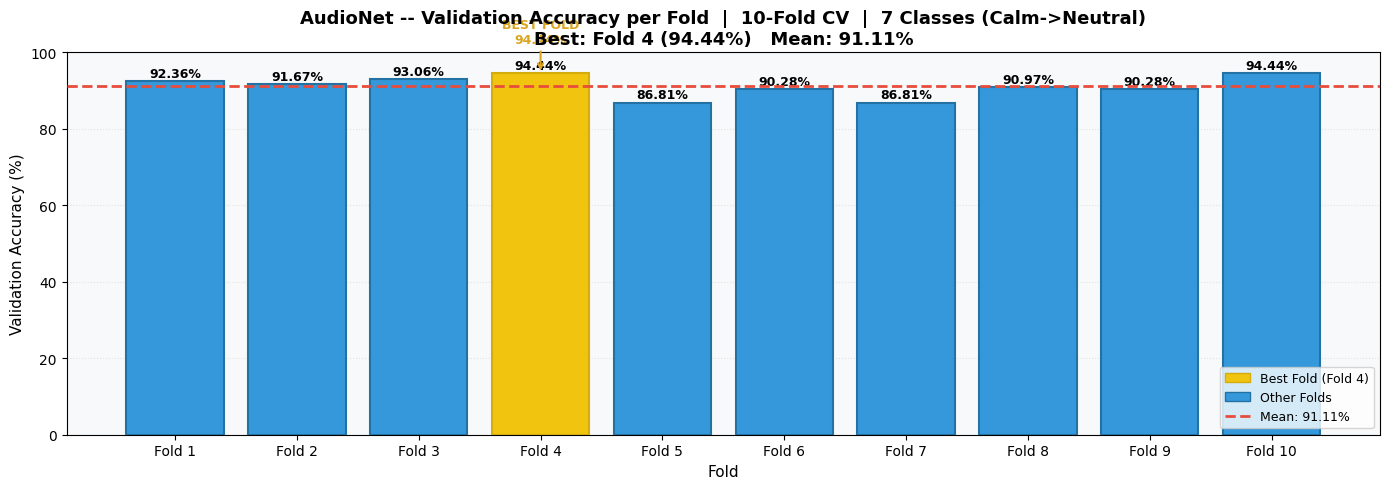

Bar chart saved --> /kaggle/working/fold_accuracy_comparison.png


In [11]:
## Cell 9c -- Bar Chart: Val Accuracy Across All Folds
# Visual comparison of all fold accuracies with best fold highlighted.

import matplotlib.pyplot as plt
import numpy as np

assert audionet.trained, "Run training first!"

n_folds   = len(audionet.fold_accuracies)
avg_acc   = sum(audionet.fold_accuracies) / n_folds
fold_nums = [f"Fold {i+1}" for i in range(n_folds)]
colors    = ['#f1c40f' if (i+1) == audionet.best_fold_idx else '#3498db'
             for i in range(n_folds)]
edge_cols = ['#d4ac0d' if (i+1) == audionet.best_fold_idx else '#2471a3'
             for i in range(n_folds)]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(fold_nums,
              [v * 100 for v in audionet.fold_accuracies],
              color=colors, edgecolor=edge_cols, linewidth=1.5, zorder=3)

ax.axhline(avg_acc * 100, color='#e74c3c', linestyle='--', linewidth=2.0,
           label=f'Mean Val Acc: {avg_acc*100:.2f}%', zorder=4)

for bar, acc in zip(bars, audionet.fold_accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{acc*100:.2f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

best_bar = bars[audionet.best_fold_idx - 1]
ax.annotate(f'BEST FOLD\n{audionet.best_fold_acc*100:.2f}%',
            xy=(best_bar.get_x() + best_bar.get_width()/2, best_bar.get_height()),
            xytext=(0, 22), textcoords='offset points',
            ha='center', fontsize=9, fontweight='bold', color='goldenrod',
            arrowprops=dict(arrowstyle='->', color='goldenrod', lw=1.5))

ax.set_title(
    f"AudioNet -- Validation Accuracy per Fold  |  {n_folds}-Fold CV  |  7 Classes (Calm->Neutral)\n"
    f"Best: Fold {audionet.best_fold_idx} ({audionet.best_fold_acc*100:.2f}%)   "
    f"Mean: {avg_acc*100:.2f}%",
    fontsize=13, fontweight='bold')
ax.set_xlabel("Fold", fontsize=11)
ax.set_ylabel("Validation Accuracy (%)", fontsize=11)
ax.set_ylim(0, min(100, max(audionet.fold_accuracies)*100 + 10))
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.set_facecolor('#f8f9fa')

from matplotlib.patches import Patch
import matplotlib.lines as mlines
ax.legend(handles=[
    Patch(facecolor='#f1c40f', edgecolor='#d4ac0d', label=f'Best Fold (Fold {audionet.best_fold_idx})'),
    Patch(facecolor='#3498db', edgecolor='#2471a3', label='Other Folds'),
    mlines.Line2D([], [], color='#e74c3c', linestyle='--', linewidth=2,
                  label=f'Mean: {avg_acc*100:.2f}%')
], fontsize=9, loc='lower right')

plt.tight_layout()
save_path = '/kaggle/working/fold_accuracy_comparison.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Bar chart saved --> {save_path}")


In [16]:
## Cell 9d -- Save & Verify Best Fold Model

import shutil, os
import numpy as np

assert audionet.trained, "Run training first!"
assert audionet.best_weight_path, "No best weights found!"

print("=" * 58)
print(f"  Best Fold         : Fold {audionet.best_fold_idx}")
print(f"  Best Val Accuracy : {audionet.best_fold_acc*100:.2f}%")
print(f"  Weights path      : {audionet.best_weight_path}")
print(f"  Keras model path  : {audionet.best_keras_path}")
print("=" * 58)

# Reload and verify
best_model = audionet.create_model()
best_model.load_weights(audionet.best_weight_path)
print("\nBest fold weights loaded into fresh model.")

n_check  = min(200, len(y_source))
idx_chk  = np.random.choice(len(y_source), n_check, replace=False)
eval_res = best_model.evaluate(x_source[idx_chk], y_source[idx_chk], verbose=0)
print(f"   Sanity-check accuracy ({n_check} samples) : {eval_res[1]*100:.2f}%")

# Copy to /kaggle/working for download
working_weights = '/kaggle/working/best_fold.weights.h5'
working_keras   = '/kaggle/working/best_fold_model.keras'

shutil.copyfile(audionet.best_weight_path, working_weights)
print(f"\nWeights copied   --> {working_weights}")

if audionet.best_keras_path and os.path.exists(audionet.best_keras_path):
    if os.path.isdir(audionet.best_keras_path):
        if os.path.exists(working_keras):
            shutil.rmtree(working_keras)
        shutil.copytree(audionet.best_keras_path, working_keras)
    else:
        shutil.copyfile(audionet.best_keras_path, working_keras)
    print(f"Full model copied --> {working_keras}")

# Fusion usage instructions
print()
print("=" * 58)
print("  HOW TO USE FOR FACE+AUDIO FUSION")
print("=" * 58)
print()
print("  # 1. Load the best model")
print(f"  best_model = audionet.create_model()")
print(f"  best_model.load_weights('{working_weights}')")
print()
print("  # OR load full SavedModel:")
print(f"  best_model = keras.models.load_model('{working_keras}')")
print()
print("  # 2. Get audio probabilities  (x_new shape: (N, seq_len, 39))")
print("  audio_probs = best_model.predict(x_new)   # shape: (N, 7)")
print()
print("  # 3. Class labels (7 -- aligned with FER-2013)")
print(f"  LABELS = {list(audionet.class_label)}")
print("  #        0       1        2      3       4        5     6")
print("  #      angry  disgust  fear  happy  neutral   sad  surprise")
print()
print("  # 4. Weighted fusion with FER-2013 face model")
print("  alpha = 0.6   # audio weight")
print("  fused_probs = alpha * audio_probs + (1 - alpha) * face_probs")
print("  predictions = np.argmax(fused_probs, axis=1)")
print("  emotions    = [LABELS[p] for p in predictions]")


  Best Fold         : Fold 4
  Best Val Accuracy : 94.44%
  Weights path      : ./Models/RAVDE_46_2026-02-28_18-16-15/BEST_fold.weights.h5
  Keras model path  : ./Models/RAVDE_46_2026-02-28_18-16-15/BEST_fold_model.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 272 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Best fold weights loaded into fresh model.
   Sanity-check accuracy (200 samples) : 99.50%

Weights copied   --> /kaggle/working/best_fold.weights.h5
Full model copied --> /kaggle/working/best_fold_model.keras

  HOW TO USE FOR FACE+AUDIO FUSION

  # 1. Load the best model
  best_model = audionet.create_model()
  best_model.load_weights('/kaggle/working/best_fold.weights.h5')

  # OR load full SavedModel:
  best_model = keras.models.load_model('/kaggle/working/best_fold_model.keras')

  # 2. Get audio probabilities  (x_new shape: (N, seq_len, 39))
  audio_probs = best_model.predict(x_new)   # shape: (N, 7)

  # 3. Class labels (7 -- aligned with FER-2013)
  LABELS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  #        0       1        2      3       4        5     6
  #      angry  disgust  fear  happy  neutral   sad  surprise

  # 4. Weighted fusion with FER-2013 face model
  alpha = 0.6   # audio weight
  fused_probs = alpha * audio_probs + (1 - alpha) * fa

## Cell 10 — Confusion Matrix & Per-class Results

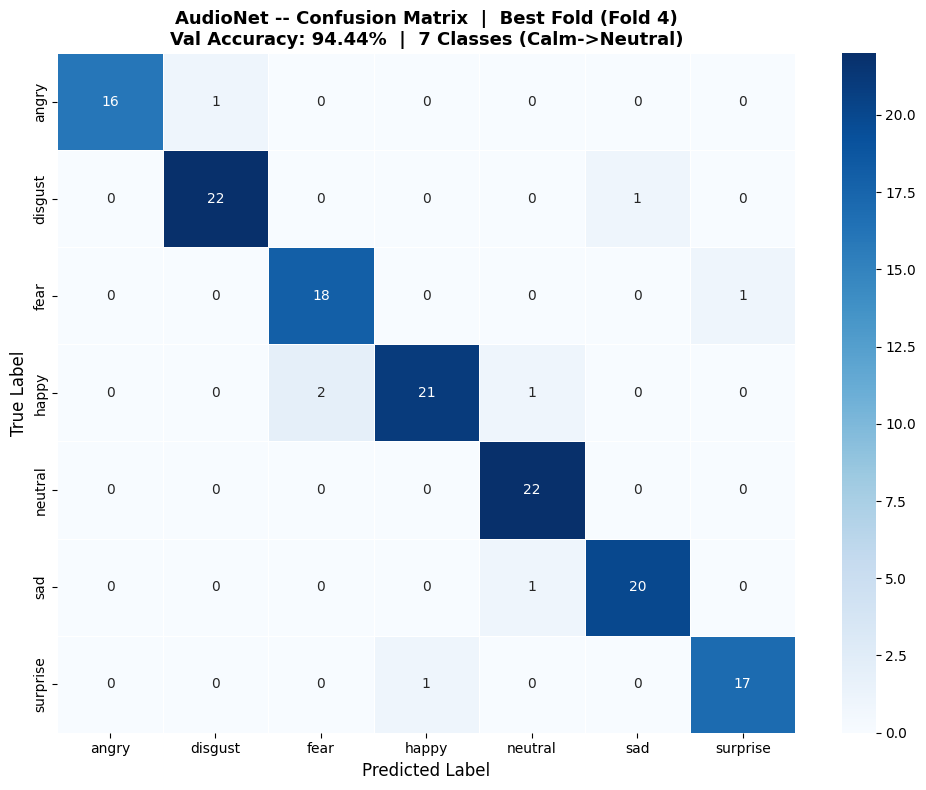


Per-Class Results (Best Fold -- Fold 4):
----------------------------------------------------
  angry      | F1: 0.970 | Prec: 1.000 | Rec: 0.941 | Support: 17
  disgust    | F1: 0.957 | Prec: 0.957 | Rec: 0.957 | Support: 23
  fear       | F1: 0.923 | Prec: 0.900 | Rec: 0.947 | Support: 19
  happy      | F1: 0.913 | Prec: 0.955 | Rec: 0.875 | Support: 24
  neutral    | F1: 0.957 | Prec: 0.917 | Rec: 1.000 | Support: 22
  sad        | F1: 0.952 | Prec: 0.952 | Rec: 0.952 | Support: 21
  surprise   | F1: 0.944 | Prec: 0.944 | Rec: 0.944 | Support: 18

Confusion matrix saved!


In [17]:
import seaborn as sns

best_fold_matrix = audionet.matrix[audionet.best_fold_idx - 1]

plt.figure(figsize=(10, 8))
sns.heatmap(
    best_fold_matrix,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=RAVDE_CLASS_LABELS,
    yticklabels=RAVDE_CLASS_LABELS,
    linewidths=0.5)
plt.title(
    f'AudioNet -- Confusion Matrix  |  Best Fold (Fold {audionet.best_fold_idx})\n'
    f'Val Accuracy: {audionet.best_fold_acc*100:.2f}%  |  7 Classes (Calm->Neutral)',
    fontsize=13, fontweight='bold')
plt.ylabel('True Label',      fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_best_fold.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPer-Class Results (Best Fold -- Fold {audionet.best_fold_idx}):")
print("-" * 52)
best_report = audionet.eva_matrix[audionet.best_fold_idx - 1]
for emotion in RAVDE_CLASS_LABELS:
    if emotion in best_report:
        f1   = best_report[emotion]['f1-score']
        prec = best_report[emotion]['precision']
        rec  = best_report[emotion]['recall']
        supp = int(best_report[emotion]['support'])
        print(f"  {emotion:<10} | F1: {f1:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | Support: {supp}")
print("\nConfusion matrix saved!")


## Cell 11 — Save Model & Final Summary

In [18]:
import shutil

if os.path.exists('./Models'):
    if os.path.exists('/kaggle/working/Final_AudioNet_Model'):
        shutil.rmtree('/kaggle/working/Final_AudioNet_Model')
    shutil.copytree('./Models', '/kaggle/working/Final_AudioNet_Model')
    print("✅ Model saved → /kaggle/working/Final_AudioNet_Model")

if os.path.exists('./Results'):
    if os.path.exists('/kaggle/working/Results'):
        shutil.rmtree('/kaggle/working/Results')
    shutil.copytree('./Results', '/kaggle/working/Results')
    print("✅ Results saved → /kaggle/working/Results")

print(f"""{'='*55} ✅  AudioNet — TRAINING SUMMARY{'='*55}
   Model         : AudioNet
   Dataset       : RAVDESS
   Classes       : 8 emotions (all included)
   Folds         : 10-fold Cross Validation
   Epochs/fold   : {args['epoch']}
   Batch Size    : {args['batch_size']}
   Learning Rate : {args['lr']}
   Final Accuracy: {round(final_accuracy*100, 2)}%{'='*55}
   📁 Output Files:
   → /kaggle/working/Final_AudioNet_Model/
   → /kaggle/working/Results/
   → /kaggle/working/confusion_matrix.png
   → /kaggle/working/data_visualization.png{'='*55}""")

✅ Model saved → /kaggle/working/Final_AudioNet_Model
======================================================= ✅  AudioNet — TRAINING SUMMARY=======================================================
   Model         : AudioNet
   Dataset       : RAVDESS
   Classes       : 8 emotions (all included)
   Folds         : 10-fold Cross Validation
   Epochs/fold   : 500
   Batch Size    : 64
   Learning Rate : 0.001
   Final Accuracy: 91.11%=======================================================
   📁 Output Files:
   → /kaggle/working/Final_AudioNet_Model/
   → /kaggle/working/Results/
   → /kaggle/working/confusion_matrix.png
   → /kaggle/working/data_visualization.png=======================================================


In [19]:
import os
import shutil

# -----------------------------
# COPY MODELS FOLDER
# -----------------------------
if os.path.exists('./Models'):
    dest_model = '/kaggle/working/Final_AudioNet_Model'
    if os.path.exists(dest_model):
        shutil.rmtree(dest_model)
    shutil.copytree('./Models', dest_model)
    print("✅ Model saved → /kaggle/working/Final_AudioNet_Model")

# -----------------------------
# COPY RESULTS FOLDER
# -----------------------------
if os.path.exists('./Results'):
    dest_results = '/kaggle/working/Results'
    if os.path.exists(dest_results):
        shutil.rmtree(dest_results)
    shutil.copytree('./Results', dest_results)
    print("✅ Results saved → /kaggle/working/Results")

# -----------------------------
# ZIP THE COMPLETE WORKING FOLDER
# -----------------------------
zip_path = "/kaggle/working/AudioNet_Complete_Output3"
shutil.make_archive(zip_path, 'zip', "/kaggle/working")

print("📦 Zipped → /kaggle/working/AudioNet_Complete_Output.zip")

# -----------------------------
# TRAINING SUMMARY
# -----------------------------
print(f"""{'='*55} ✅  AudioNet — TRAINING SUMMARY{'='*55}
   Model         : AudioNet
   Dataset       : RAVDESS
   Classes       : 8 emotions (all included)
   Folds         : 10-fold Cross Validation
   Epochs/fold   : {args['epoch']}
   Batch Size    : {args['batch_size']}
   Learning Rate : {args['lr']}
   Final Accuracy: {round(final_accuracy*100, 2)}% {'='*55}
   📁 Output Files:
   → /kaggle/working/Final_AudioNet_Model/
   → /kaggle/working/Results/
   → /kaggle/working/confusion_matrix.png
   → /kaggle/working/data_visualization.png
   → /kaggle/working/AudioNet_Complete_Output.zip {'='*55}""")

✅ Model saved → /kaggle/working/Final_AudioNet_Model
📦 Zipped → /kaggle/working/AudioNet_Complete_Output.zip
======================================================= ✅  AudioNet — TRAINING SUMMARY=======================================================
   Model         : AudioNet
   Dataset       : RAVDESS
   Classes       : 8 emotions (all included)
   Folds         : 10-fold Cross Validation
   Epochs/fold   : 500
   Batch Size    : 64
   Learning Rate : 0.001
   Final Accuracy: 91.11% =======================================================
   📁 Output Files:
   → /kaggle/working/Final_AudioNet_Model/
   → /kaggle/working/Results/
   → /kaggle/working/confusion_matrix.png
   → /kaggle/working/data_visualization.png
   → /kaggle/working/AudioNet_Complete_Output.zip =======================================================


In [20]:
!ls -R /kaggle/working

/kaggle/working:
AudioNet_Complete_Output3.zip	Final_AudioNet_Model
best_fold_model.keras		fold_accuracy_comparison.png
best_fold.weights.h5		Models
confusion_matrix_best_fold.png	train_val_accuracy_all_folds.png
data_visualization.png

/kaggle/working/Final_AudioNet_Model:
RAVDE_46_2026-02-28_17-53-03  RAVDE_46_2026-02-28_18-16-15

/kaggle/working/Final_AudioNet_Model/RAVDE_46_2026-02-28_17-53-03:
10-fold_weights_temp_2.weights.h5  BEST_fold.weights.h5

/kaggle/working/Final_AudioNet_Model/RAVDE_46_2026-02-28_18-16-15:
BEST_fold_model.keras  BEST_fold.weights.h5

/kaggle/working/Models:
RAVDE_46_2026-02-28_17-53-03  RAVDE_46_2026-02-28_18-16-15

/kaggle/working/Models/RAVDE_46_2026-02-28_17-53-03:
10-fold_weights_temp_2.weights.h5  BEST_fold.weights.h5

/kaggle/working/Models/RAVDE_46_2026-02-28_18-16-15:
BEST_fold_model.keras  BEST_fold.weights.h5


In [21]:
## Cell — Zip /kaggle/working folder for download

import shutil, os

zip_output_path = '/kaggle/working/AudioNet_Final_Output'

# Remove old zip if exists (can't zip into itself cleanly otherwise)
if os.path.exists(zip_output_path + '.zip'):
    os.remove(zip_output_path + '.zip')

# Create zip of everything in /kaggle/working
# We zip the contents, not the folder itself, to keep paths clean
shutil.make_archive(
    base_name = zip_output_path,   # output: /kaggle/working/AudioNet_Final_Output.zip
    format    = 'zip',
    root_dir  = '/kaggle/working', # base directory
    base_dir  = '.'                # zip everything inside it
)

zip_size = os.path.getsize(zip_output_path + '.zip') / (1024 * 1024)
print(f"Zip created --> /kaggle/working/AudioNet_Final_Output.zip")
print(f"Size        : {zip_size:.2f} MB")
print()
print("Contents zipped:")
for root, dirs, files in os.walk('/kaggle/working'):
    # Skip the zip files themselves to avoid confusion
    for file in files:
        if not file.endswith('.zip'):
            rel_path = os.path.relpath(os.path.join(root, file), '/kaggle/working')
            size_kb  = os.path.getsize(os.path.join(root, file)) / 1024
            print(f"   {rel_path:<60}  {size_kb:>8.1f} KB")

Zip created --> /kaggle/working/AudioNet_Final_Output.zip
Size        : 25.28 MB

Contents zipped:
   confusion_matrix_best_fold.png                                    80.7 KB
   data_visualization.png                                           182.4 KB
   fold_accuracy_comparison.png                                      82.1 KB
   best_fold_model.keras                                           1891.1 KB
   best_fold.weights.h5                                            1758.2 KB
   train_val_accuracy_all_folds.png                                 753.1 KB
   .virtual_documents/__notebook_source__.ipynb                      35.5 KB
   Models/RAVDE_46_2026-02-28_18-16-15/BEST_fold_model.keras       1891.1 KB
   Models/RAVDE_46_2026-02-28_18-16-15/BEST_fold.weights.h5        1758.2 KB
   Models/RAVDE_46_2026-02-28_17-53-03/BEST_fold.weights.h5        1758.2 KB
   Models/RAVDE_46_2026-02-28_17-53-03/10-fold_weights_temp_2.weights.h5    1758.2 KB
   Final_AudioNet_Model/RAVDE_46_2026-02-28_1

In [22]:
!ls -R /kaggle/working

/kaggle/working:
AudioNet_Complete_Output3.zip	data_visualization.png
AudioNet_Final_Output.zip	Final_AudioNet_Model
best_fold_model.keras		fold_accuracy_comparison.png
best_fold.weights.h5		Models
confusion_matrix_best_fold.png	train_val_accuracy_all_folds.png

/kaggle/working/Final_AudioNet_Model:
RAVDE_46_2026-02-28_17-53-03  RAVDE_46_2026-02-28_18-16-15

/kaggle/working/Final_AudioNet_Model/RAVDE_46_2026-02-28_17-53-03:
10-fold_weights_temp_2.weights.h5  BEST_fold.weights.h5

/kaggle/working/Final_AudioNet_Model/RAVDE_46_2026-02-28_18-16-15:
BEST_fold_model.keras  BEST_fold.weights.h5

/kaggle/working/Models:
RAVDE_46_2026-02-28_17-53-03  RAVDE_46_2026-02-28_18-16-15

/kaggle/working/Models/RAVDE_46_2026-02-28_17-53-03:
10-fold_weights_temp_2.weights.h5  BEST_fold.weights.h5

/kaggle/working/Models/RAVDE_46_2026-02-28_18-16-15:
BEST_fold_model.keras  BEST_fold.weights.h5
